# mHealth Dataset 기반 CNN 분류

### 결과 분석

CNN3 Test accuracy: 96.60%

CNN4 Test accuracy: 97.61%

CNN5 Test accuracy: 95.47%

CNN3, CNN4, CNN5는 각각 test accuracy 96.60%, 97.61%, 95.47%를 기록하였지만 그 중 CNN4가 가장 높은 성능을 보였다.

CNN4가 가장 높은 성능을 보인 이유는 4층 Conv1D로 충분한 표현력을 확보하면서도 MaxPool을 1회만 적용해 시간 정보를 보존했기 때문으로 해석된다.

반면 CNN5는 파라미터가 가장 많음에도 가장 낮은 성능을 보였다.

Lying down의 recall이 0.5000으로 낮고 Sitting and relaxing의 precision이 0.6667로 낮게 나타났다.

-> CNN5의 성능 저하는 Lying down과 Sitting처럼 움직임 변화가 적은 정적 자세 간 혼동에서 주로 발생한 것으로 해석된다.

따라서 단순한 depth 증가가 성능 향상을 보장하지 않으며 CNN4가 가장 적절한 균형을 보인 구조라고 판단된다.

In [76]:
# 라이브러리 import
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, MaxPool1D,
    GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [77]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
import os
import pandas as pd

# mHealth raw 데이터 로드
base_dir = "/content/drive/MyDrive"

FEATURE_COLUMNS = [f'sensor_{i+1}' for i in range(23)]
LABEL_COLUMN = 'label'
SUBJECT_COLUMN = 'subject'

LABELS = [
    'Standing still',
    'Sitting and relaxing',
    'Lying down',
    'Walking',
    'Climbing stairs',
    'Waist bends forward',
    'Frontal elevation of arms',
    'Knees bending',
    'Cycling',
    'Jogging',
    'Running',
    'Jump front and back'
]

dfs = []

for i in range(1, 11):
    path = os.path.join(base_dir, f"mHealth_subject{i}.log")

    df_i = pd.read_csv(path, sep=r"\s+", header=None)
    df_i.columns = FEATURE_COLUMNS + [LABEL_COLUMN]
    df_i[SUBJECT_COLUMN] = i

    dfs.append(df_i)

data = pd.concat(dfs, ignore_index=True)

print(data.shape)
print(data.head())

## 데이터 전처리

1. **mHealth 로그 파일 로드**
2. **클린업**: 라벨 0 제거, 23개 센서 컬럼을 float32로 변환
3. **Label Encoding**: mHealth activity 이름을 정수 라벨로 변환
4. **Data Split (subject 기반)**:
  - subject 1~7: train
  - subject 8: validation
  - subject 9~10: test
5. **정규화**: StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation**: sliding window (TIME_STEPS=200, STEP=40)


In [80]:
# 클린업
# 라벨 0은 비활동/전환 구간이므로 실제 12개 activity만 사용
df = data[data[LABEL_COLUMN] > 0].copy()

# 센서 값을 float32 숫자형으로 변환
for col in FEATURE_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float32)

df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(np.int32)
df[SUBJECT_COLUMN] = df[SUBJECT_COLUMN].astype(np.int32)
df = df.dropna().reset_index(drop=True)

# 라벨 번호를 activity 이름으로 변환
df['activity'] = df[LABEL_COLUMN].map(lambda label: LABELS[label - 1])

In [81]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print()
print('Label mapping:', dict(enumerate(label_encoder.classes_)))



Label mapping: {0: 'Climbing stairs', 1: 'Cycling', 2: 'Frontal elevation of arms', 3: 'Jogging', 4: 'Jump front and back', 5: 'Knees bending', 6: 'Lying down', 7: 'Running', 8: 'Sitting and relaxing', 9: 'Standing still', 10: 'Waist bends forward', 11: 'Walking'}


In [82]:
# Data Split (subject 기반)
# subject 1~7 = train set
# subject 8 = validation set
# subject 9~10 = test set
TRAIN_SUBJECTS = list(range(1, 8))
VAL_SUBJECTS = [8]
TEST_SUBJECTS = [9, 10]

df_train = df[df[SUBJECT_COLUMN].isin(TRAIN_SUBJECTS)].copy()
df_val   = df[df[SUBJECT_COLUMN].isin(VAL_SUBJECTS)].copy()
df_test  = df[df[SUBJECT_COLUMN].isin(TEST_SUBJECTS)].copy()

In [83]:
# 정규화
scaler = StandardScaler()

df_train.loc[:, FEATURE_COLUMNS] = scaler.fit_transform(df_train.loc[:, FEATURE_COLUMNS])

if not df_val.empty:
    df_val.loc[:, FEATURE_COLUMNS] = scaler.transform(df_val.loc[:, FEATURE_COLUMNS])

if not df_test.empty:
    df_test.loc[:, FEATURE_COLUMNS] = scaler.transform(df_test.loc[:, FEATURE_COLUMNS])


In [84]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
# subject와 activity segment 경계를 넘는 window가 생기지 않도록 그룹별로 생성
def create_dataset(df_split, time_steps=200, step=40):
    xs, ys = [], []

    if df_split.empty:
        return np.empty((0, time_steps, len(FEATURE_COLUMNS)), dtype=np.float32), np.empty((0,), dtype=np.int32)

    df_split = df_split.copy()
    segment_id = df_split.groupby(SUBJECT_COLUMN)['activity_encoded'].transform(lambda s: s.ne(s.shift()).cumsum())
    df_split['segment'] = segment_id

    for _, segment in df_split.groupby([SUBJECT_COLUMN, 'segment'], sort=False):
        x_values = segment[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        y_value = int(segment['activity_encoded'].iloc[0])

        for i in range(0, len(x_values) - time_steps + 1, step):
            xs.append(x_values[i:i + time_steps])
            ys.append(y_value)

    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int32)


TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train, TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val,   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test,  TIME_STEPS, STEP)

print()
print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_val  : {x_val.shape},  y_val  : {y_val.shape}')
print(f'x_test : {x_test.shape},  y_test : {y_test.shape}')
print('train label distribution:', np.bincount(y_train, minlength=num_classes))
print('val label distribution:', np.bincount(y_val, minlength=num_classes))
print('test label distribution:', np.bincount(y_test, minlength=num_classes))



x_train: (5650, 200, 23), y_train: (5650,)
x_val  : (777, 200, 23),  y_val  : (777,)
x_test : (1588, 200, 23),  y_test : (1588,)
train label distribution: [504 504 488 504 148 492 504 504 504 504 490 504]
val label distribution: [72 72 71 72 21 60 72 72 72 72 49 72]
test label distribution: [144 144 132 144  43 137 144 144 144 144 124 144]


In [85]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록
classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print('Class weights:', class_weights_dict)


Class weights: {np.int32(0): np.float64(0.9341931216931217), np.int32(1): np.float64(0.9341931216931217), np.int32(2): np.float64(0.9648224043715847), np.int32(3): np.float64(0.9341931216931217), np.int32(4): np.float64(3.1813063063063063), np.int32(5): np.float64(0.9569783197831978), np.int32(6): np.float64(0.9341931216931217), np.int32(7): np.float64(0.9341931216931217), np.int32(8): np.float64(0.9341931216931217), np.int32(9): np.float64(0.9341931216931217), np.int32(10): np.float64(0.9608843537414966), np.int32(11): np.float64(0.9341931216931217)}


## Model 1
- CNN 3 (Conv1D 3개)

In [86]:
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model1 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model1.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model1.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 200, 64)        │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_24 (ReLU)                 │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,804 (382.05 KB)

 Trainable params: 97,164 (379.55 KB)

 Non-trainable params: 640 (2.50 KB)

None


In [87]:
callbacks1 = [
    ModelCheckpoint(
        'mHealth_CNN3_best.h5',
        save_best_only=True,
        monitor='val_sparse_categorical_accuracy',
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_sparse_categorical_accuracy',
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history1 = model1.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks1,
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.5979 - sparse_categorical_accuracy: 0.5248
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.72201, saving model to mHealth_CNN3_best.h5



Epoch 1: finished saving model to mHealth_CNN3_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - loss: 1.0123 - sparse_categorical_accuracy: 0.7381 - val_loss: 1.1912 - val_sparse_categorical_accuracy: 0.7220 - learning_rate: 5.0000e-04
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2025 - sparse_categorical_accuracy: 0.9672
Epoch 2: val_sparse_categorical_accuracy improved from 0.72201 to 0.77091, saving model to mHealth_CNN3_best.h5



Epoch 2: finished saving model to mHealth_CNN3_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1493 - sparse_categorical_accuracy: 0.9765 - val_loss: 0.5309 - val_sparse_categorical_accuracy: 0.7709 - learning_rate: 5.0000e-04
Epoch 3/100
80/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0617 - sparse_categorical_accuracy: 0.9903
Epoch 3: val_sparse_categorical_accuracy improved from 0.77091 to 0.85972, saving model to mHealth_CNN3_best.h5



Epoch 3: finished saving model to mHealth_CNN3_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0521 - sparse_categorical_accuracy: 0.9915 - val_loss: 0.3169 - val_sparse_categorical_accuracy: 0.8597 - learning_rate: 5.0000e-04
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0290 - sparse_categorical_accuracy: 0.9961
Epoch 4: val_sparse_categorical_accuracy improved from 0.85972 to 0.89575, saving model to mHealth_CNN3_best.h5



Epoch 4: finished saving model to mHealth_CNN3_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0285 - sparse_categorical_accuracy: 0.9963 - val_loss: 0.2508 - val_sparse_categorical_accuracy: 0.8958 - learning_rate: 5.0000e-04
Epoch 5/100
83/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0163 - sparse_categorical_accuracy: 0.9995
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.89575
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0155 - sparse_categorical_accuracy: 0.9993 - val_loss: 0.2965 - val_sparse_categorical_accuracy: 0.8867 - learning_rate: 5.0000e-04
Epoch 6/100
81/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0138 - sparse_categorical_accuracy: 0.9978
Epoch 6: val_sparse_categorical_accuracy did not improve from 0.89575
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0122 - sparse_categorical_accuracy: 0.9988 - val_loss: 0.4146 - val_sparse_categorical_accuracy: 0.8674 - learning_rate: 5.0000e-04
Epoch 7/100
83/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - 


Epoch 7: finished saving model to mHealth_CNN3_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0082 - sparse_categorical_accuracy: 0.9998 - val_loss: 0.3840 - val_sparse_categorical_accuracy: 0.8970 - learning_rate: 5.0000e-04
Epoch 8/100
81/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - sparse_categorical_accuracy: 0.9994
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.89704
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0065 - sparse_categorical_accuracy: 0.9995 - val_loss: 0.4526 - val_sparse_categorical_accuracy: 0.8777 - learning_rate: 5.0000e-04
Epoch 9/100
80/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - sparse_categorical_accuracy: 1.0000
Epoch 9: val_sparse_categorical_accuracy did not improve from 0.89704

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0042 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.4509 - val_sparse_categorical_accuracy: 0.8932 - le


Epoch 13: finished saving model to mHealth_CNN3_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - sparse_categorical_accuracy: 0.9998 - val_loss: 0.5134 - val_sparse_categorical_accuracy: 0.8996 - learning_rate: 2.5000e-04
Epoch 14/100
85/89 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0021 - sparse_categorical_accuracy: 1.0000
Epoch 14: val_sparse_categorical_accuracy did not improve from 0.89961

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0022 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.5708 - val_sparse_categorical_accuracy: 0.8945 - learning_rate: 2.5000e-04
Epoch 15/100
87/89 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0030 - sparse_categorical_accuracy: 1.0000
Epoch 15: val_sparse_categorical_accuracy did not improve from 0.89961
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0034 - sparse_categorical_accuracy: 0.9998 - val_loss: 0.6225 - val_sparse_categorical_accuracy: 

In [88]:
# 모델 평가
model1 = tf.keras.models.load_model('mHealth_CNN3_best.h5')

train_loss, train_acc = model1.evaluate(x_train, y_train, verbose=0)
print(f'Training accuracy: {train_acc * 100:.2f}%')
print(f'Training loss: {train_loss:.4f}')

test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc * 100:.2f}%')
print(f'Test loss: {test_loss:.4f}')


Training accuracy: 100.00%
Training loss: 0.0001
Test accuracy: 96.60%
Test loss: 0.0785


In [89]:
y_pred_proba = model1.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     0.7579    1.0000    0.8623       144
                  Cycling     1.0000    1.0000    1.0000       144
Frontal elevation of arms     0.9429    1.0000    0.9706       132
                  Jogging     1.0000    1.0000    1.0000       144
      Jump front and back     1.0000    1.0000    1.0000        43
            Knees bending     1.0000    1.0000    1.0000       137
               Lying down     1.0000    1.0000    1.0000       144
                  Running     1.0000    1.0000    1.0000       144
     Sitting and relaxing     1.0000    0.9444    0.9714       144
           Standing still     1.0000    1.0000    1.0000       144
      Waist bends forward     1.0000    1.0000    1.0000       124
                  Walking     1.0000    0.6806    0.8099       144

                 accuracy                         0.9660      1588
                macro avg     0.9751

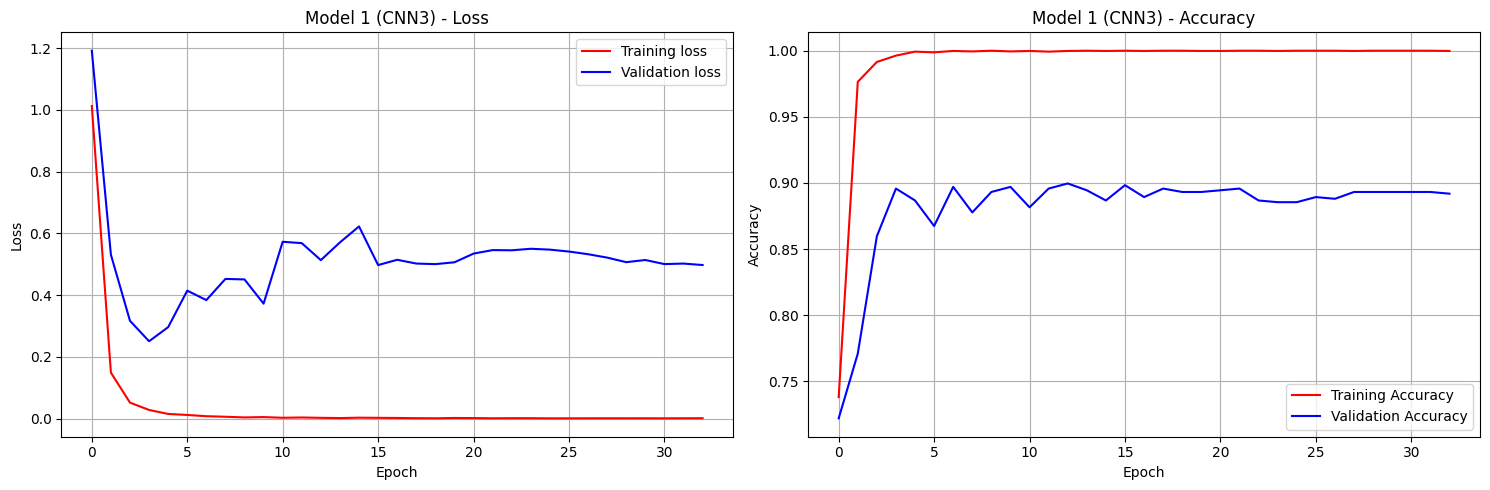

In [90]:
train_loss = history1.history['loss']
train_accuracy = history1.history['sparse_categorical_accuracy']
val_loss = history1.history['val_loss']
val_accuracy = history1.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 1 (CNN3) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 1 (CNN3) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

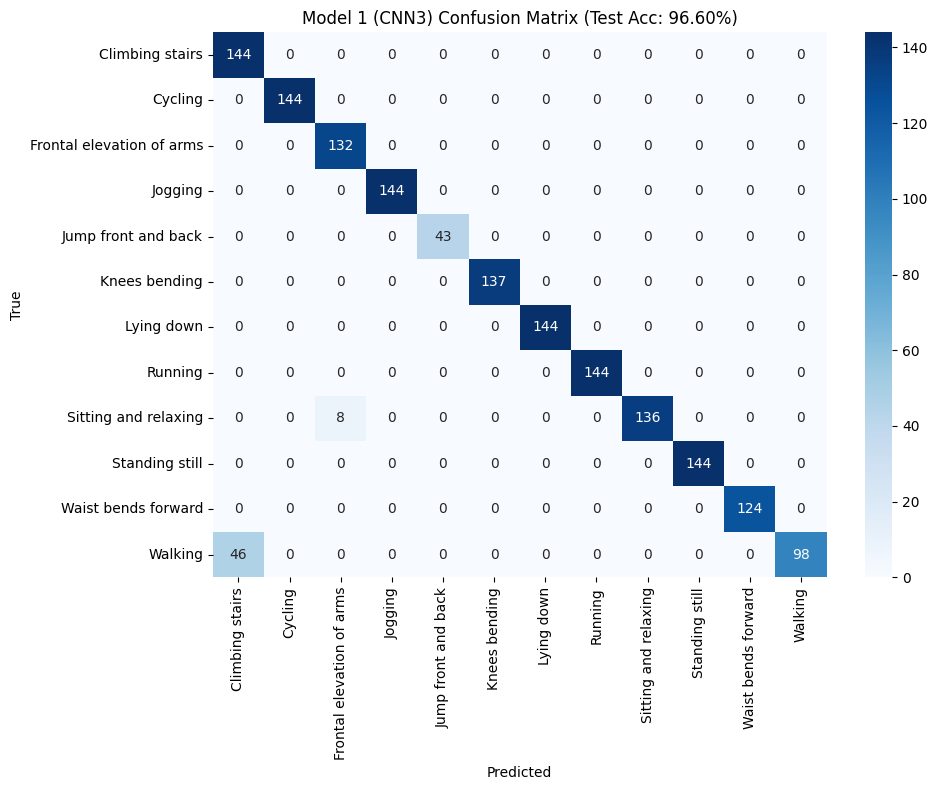

In [91]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 1 (CNN3) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Model 2
- CNN 4 (Conv1D 4개)

In [92]:
model2 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model2.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model2.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_27 (Conv1D)              │ (None, 200, 64)        │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_29 (ReLU)                 │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_30 (ReLU)                 │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,596 (576.55 KB)

 Trainable params: 146,700 (573.05 KB)

 Non-trainable params: 896 (3.50 KB)

None


In [93]:
callbacks2 = [
    ModelCheckpoint(
        'mHealth_CNN4_best.h5',
        save_best_only=True,
        monitor='val_sparse_categorical_accuracy',
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_sparse_categorical_accuracy',
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history2 = model2.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks2,
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.3370 - sparse_categorical_accuracy: 0.6185
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.69112, saving model to mHealth_CNN4_best.h5



Epoch 1: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 0.7656 - sparse_categorical_accuracy: 0.8127 - val_loss: 1.0917 - val_sparse_categorical_accuracy: 0.6911 - learning_rate: 5.0000e-04
Epoch 2/100
85/89 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1142 - sparse_categorical_accuracy: 0.9809
Epoch 2: val_sparse_categorical_accuracy improved from 0.69112 to 0.76834, saving model to mHealth_CNN4_best.h5



Epoch 2: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0798 - sparse_categorical_accuracy: 0.9865 - val_loss: 0.6025 - val_sparse_categorical_accuracy: 0.7683 - learning_rate: 5.0000e-04
Epoch 3/100
87/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0355 - sparse_categorical_accuracy: 0.9949
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.76834
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0316 - sparse_categorical_accuracy: 0.9945 - val_loss: 0.7218 - val_sparse_categorical_accuracy: 0.7323 - learning_rate: 5.0000e-04
Epoch 4/100
87/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0197 - sparse_categorical_accuracy: 0.9990
Epoch 4: val_sparse_categorical_accuracy improved from 0.76834 to 0.80051, saving model to mHealth_CNN4_best.h5



Epoch 4: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0163 - sparse_categorical_accuracy: 0.9991 - val_loss: 0.6239 - val_sparse_categorical_accuracy: 0.8005 - learning_rate: 5.0000e-04
Epoch 5/100
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0116 - sparse_categorical_accuracy: 0.9992
Epoch 5: val_sparse_categorical_accuracy improved from 0.80051 to 0.80309, saving model to mHealth_CNN4_best.h5



Epoch 5: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0118 - sparse_categorical_accuracy: 0.9984 - val_loss: 0.7775 - val_sparse_categorical_accuracy: 0.8031 - learning_rate: 5.0000e-04
Epoch 6/100
81/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0144 - sparse_categorical_accuracy: 0.9966
Epoch 6: val_sparse_categorical_accuracy improved from 0.80309 to 0.81338, saving model to mHealth_CNN4_best.h5


...


Epoch 7: finished saving model to mHealth_CNN4_best.h5

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0046 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.7378 - val_sparse_categorical_accuracy: 0.8275 - learning_rate: 5.0000e-04
Epoch 8/100
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036 - sparse_categorical_accuracy: 0.9995
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.82754
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0037 - sparse_categorical_accuracy: 0.9996 - val_loss: 0.8705 - val_sparse_categorical_accuracy: 0.8018 - learning_rate: 2.5000e-04
Epoch 9/100
82/89 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - sparse_categorical_accuracy: 1.0000
Epoch 9: val_sparse_categorical_accuracy improved from 0.82754 to 0.83012, saving model to mHealth_CNN4_best.h5



Epoch 9: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.8062 - val_sparse_categorical_accuracy: 0.8301 - learning_rate: 2.5000e-04
Epoch 10/100
85/89 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - sparse_categorical_accuracy: 0.9996
Epoch 10: val_sparse_categorical_accuracy did not improve from 0.83012
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0035 - sparse_categorical_accuracy: 0.9998 - val_loss: 0.8425 - val_sparse_categorical_accuracy: 0.8288 - learning_rate: 2.5000e-04
Epoch 11/100
86/89 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0023 - sparse_categorical_accuracy: 1.0000
Epoch 11: val_sparse_categorical_accuracy improved from 0.83012 to 0.83912, saving model to mHealth_CNN4_best.h5



Epoch 11: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0023 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.8007 - val_sparse_categorical_accuracy: 0.8391 - learning_rate: 2.5000e-04
Epoch 12/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022 - sparse_categorical_accuracy: 1.0000
Epoch 12: val_sparse_categorical_accuracy did not improve from 0.83912

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.9312 - val_sparse_categorical_accuracy: 0.8288 - learning_rate: 2.5000e-04
Epoch 13/100
82/89 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - sparse_categorical_accuracy: 1.0000
Epoch 13: val_sparse_categorical_accuracy did not improve from 0.83912
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.9450 - val_sparse_categorical_accuracy: 0.8


Epoch 15: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0023 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.8095 - val_sparse_categorical_accuracy: 0.8597 - learning_rate: 1.2500e-04
Epoch 16/100
82/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - sparse_categorical_accuracy: 1.0000
Epoch 16: val_sparse_categorical_accuracy improved from 0.85972 to 0.86100, saving model to mHealth_CNN4_best.h5



Epoch 16: finished saving model to mHealth_CNN4_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.8612 - val_sparse_categorical_accuracy: 0.8610 - learning_rate: 1.2500e-04
Epoch 17/100
81/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - sparse_categorical_accuracy: 0.9996
Epoch 17: val_sparse_categorical_accuracy did not improve from 0.86100

Epoch 17: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - sparse_categorical_accuracy: 0.9995 - val_loss: 0.9295 - val_sparse_categorical_accuracy: 0.8430 - learning_rate: 1.2500e-04
Epoch 18/100
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - sparse_categorical_accuracy: 1.0000
Epoch 18: val_sparse_categorical_accuracy did not improve from 0.86100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.9565 - val_sparse_categorical_accuracy: 0.8263

In [94]:
# 모델 평가
model2 = tf.keras.models.load_model('mHealth_CNN4_best.h5')

train_loss, train_acc = model2.evaluate(x_train, y_train, verbose=0)
print(f'Training accuracy: {train_acc * 100:.2f}%')
print(f'Training loss: {train_loss:.4f}')

test_loss, test_acc = model2.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc * 100:.2f}%')
print(f'Test loss: {test_loss:.4f}')


Training accuracy: 100.00%
Training loss: 0.0000
Test accuracy: 97.61%
Test loss: 0.0475


In [95]:
y_pred_proba = model2.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     0.7912    1.0000    0.8834       144
                  Cycling     1.0000    1.0000    1.0000       144
Frontal elevation of arms     1.0000    1.0000    1.0000       132
                  Jogging     1.0000    1.0000    1.0000       144
      Jump front and back     1.0000    1.0000    1.0000        43
            Knees bending     1.0000    1.0000    1.0000       137
               Lying down     1.0000    0.7361    0.8480       144
                  Running     1.0000    1.0000    1.0000       144
     Sitting and relaxing     1.0000    1.0000    1.0000       144
           Standing still     1.0000    1.0000    1.0000       144
      Waist bends forward     1.0000    1.0000    1.0000       124
                  Walking     1.0000    1.0000    1.0000       144

                 accuracy                         0.9761      1588
                macro avg     0.9826

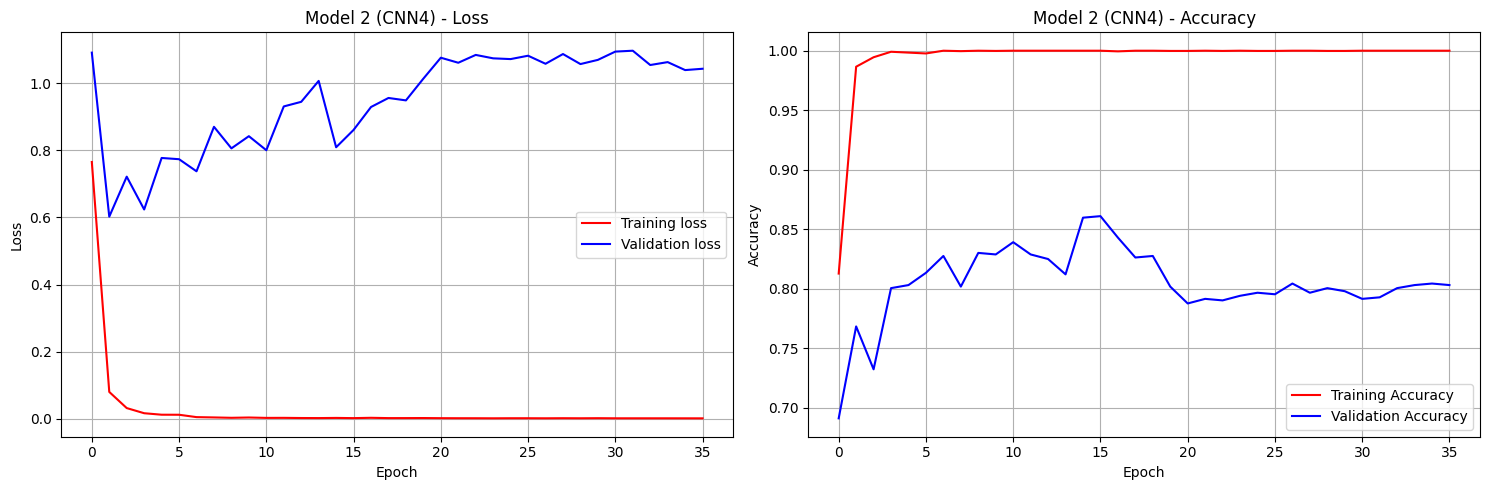

In [96]:
train_loss = history2.history['loss']
train_accuracy = history2.history['sparse_categorical_accuracy']
val_loss = history2.history['val_loss']
val_accuracy = history2.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 2 (CNN4) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 2 (CNN4) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

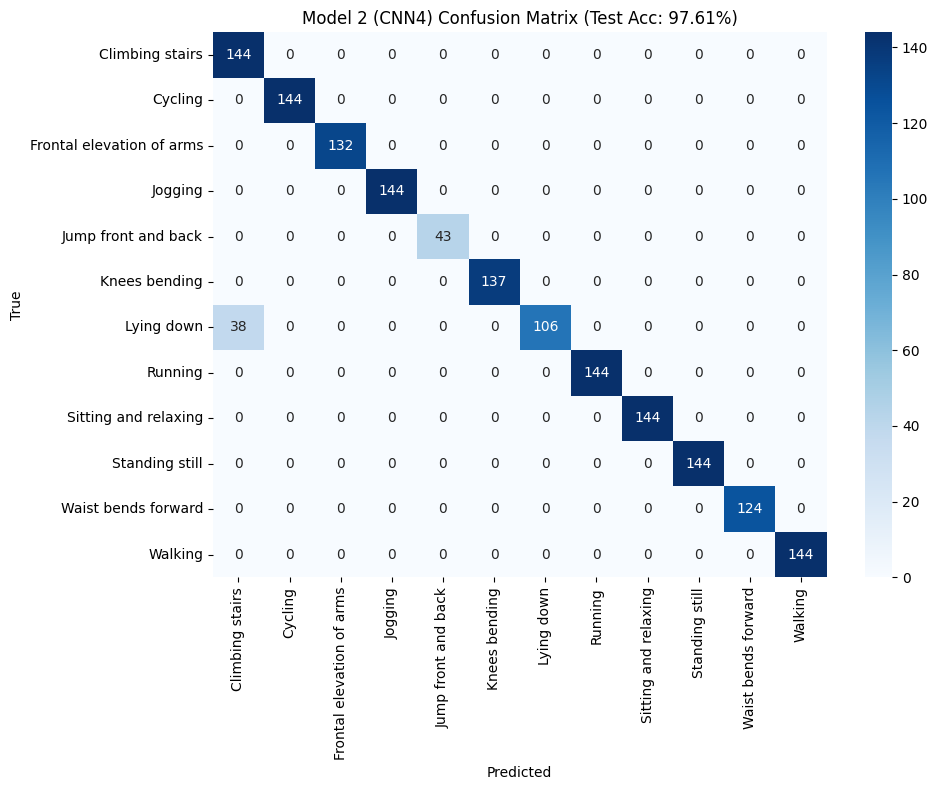

In [97]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 2 (CNN4) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Model 3
- CNN 5 (Conv1D 5개)

In [98]:
model3 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model3.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model3.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_31 (Conv1D)              │ (None, 200, 64)        │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_31 (ReLU)                 │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_32 (ReLU)                 │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 100, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_33 (ReLU)                 │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_34 (ReLU)                 │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 50, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_35 (ReLU)                 │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,660 (1.57 MB)

 Trainable params: 409,996 (1.56 MB)

 Non-trainable params: 1,664 (6.50 KB)

None


In [99]:
callbacks3 = [
    ModelCheckpoint(
        'mHealth_CNN5_best.h5',
        save_best_only=True,
        monitor='val_sparse_categorical_accuracy',
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_sparse_categorical_accuracy',
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history3 = model3.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks3,
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.0262 - sparse_categorical_accuracy: 0.6902
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.87387, saving model to mHealth_CNN5_best.h5



Epoch 1: finished saving model to mHealth_CNN5_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - loss: 0.4920 - sparse_categorical_accuracy: 0.8658 - val_loss: 1.1234 - val_sparse_categorical_accuracy: 0.8739 - learning_rate: 5.0000e-04
Epoch 2/100
87/89 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0525 - sparse_categorical_accuracy: 0.9911
Epoch 2: val_sparse_categorical_accuracy did not improve from 0.87387
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0364 - sparse_categorical_accuracy: 0.9938 - val_loss: 0.5358 - val_sparse_categorical_accuracy: 0.8623 - learning_rate: 5.0000e-04
Epoch 3/100
85/89 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0186 - sparse_categorical_accuracy: 0.9974
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.87387
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0164 - sparse_categorical_accuracy: 0.9977 - val_loss: 0.6566 - val_sparse_categorical_accuracy: 0.7696 - learning_rate: 5.0000e-04
Epoch 4/100
85/89 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/st


Epoch 8: finished saving model to mHealth_CNN5_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0020 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2056 - val_sparse_categorical_accuracy: 0.9459 - learning_rate: 5.0000e-04
Epoch 9/100
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - sparse_categorical_accuracy: 1.0000
Epoch 9: val_sparse_categorical_accuracy did not improve from 0.94595
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0014 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2408 - val_sparse_categorical_accuracy: 0.8687 - learning_rate: 5.0000e-04
Epoch 10/100
84/89 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0015 - sparse_categorical_accuracy: 1.0000
Epoch 10: val_sparse_categorical_accuracy improved from 0.94595 to 0.94723, saving model to mHealth_CNN5_best.h5



Epoch 10: finished saving model to mHealth_CNN5_best.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.2248 - val_sparse_categorical_accuracy: 0.9472 - learning_rate: 5.0000e-04
Epoch 11/100
88/89 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - sparse_categorical_accuracy: 0.9995
Epoch 11: val_sparse_categorical_accuracy did not improve from 0.94723
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0034 - sparse_categorical_accuracy: 0.9993 - val_loss: 2.1633 - val_sparse_categorical_accuracy: 0.6100 - learning_rate: 5.0000e-04
Epoch 12/100
86/89 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0238 - sparse_categorical_accuracy: 0.9926
Epoch 12: val_sparse_categorical_accuracy did not improve from 0.94723
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0135 - sparse_categorical_accuracy: 0.9963 - val_loss: 1.6214 - val_sparse_categorical_accuracy: 0.6293 - learning_rate: 5.0000e-04
Epoch 13/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [100]:
# 모델 평가
model3 = tf.keras.models.load_model('mHealth_CNN5_best.h5')

train_loss, train_acc = model3.evaluate(x_train, y_train, verbose=0)
print(f'Training accuracy: {train_acc * 100:.2f}%')
print(f'Training loss: {train_loss:.4f}')

test_loss, test_acc = model3.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc * 100:.2f}%')
print(f'Test loss: {test_loss:.4f}')


Training accuracy: 100.00%
Training loss: 0.0000
Test accuracy: 95.47%
Test loss: 0.1747


In [101]:
y_pred_proba = model3.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     1.0000    1.0000    1.0000       144
                  Cycling     1.0000    1.0000    1.0000       144
Frontal elevation of arms     1.0000    1.0000    1.0000       132
                  Jogging     1.0000    1.0000    1.0000       144
      Jump front and back     1.0000    1.0000    1.0000        43
            Knees bending     1.0000    1.0000    1.0000       137
               Lying down     1.0000    0.5000    0.6667       144
                  Running     1.0000    1.0000    1.0000       144
     Sitting and relaxing     0.6667    1.0000    0.8000       144
           Standing still     1.0000    1.0000    1.0000       144
      Waist bends forward     1.0000    1.0000    1.0000       124
                  Walking     1.0000    1.0000    1.0000       144

                 accuracy                         0.9547      1588
                macro avg     0.9722

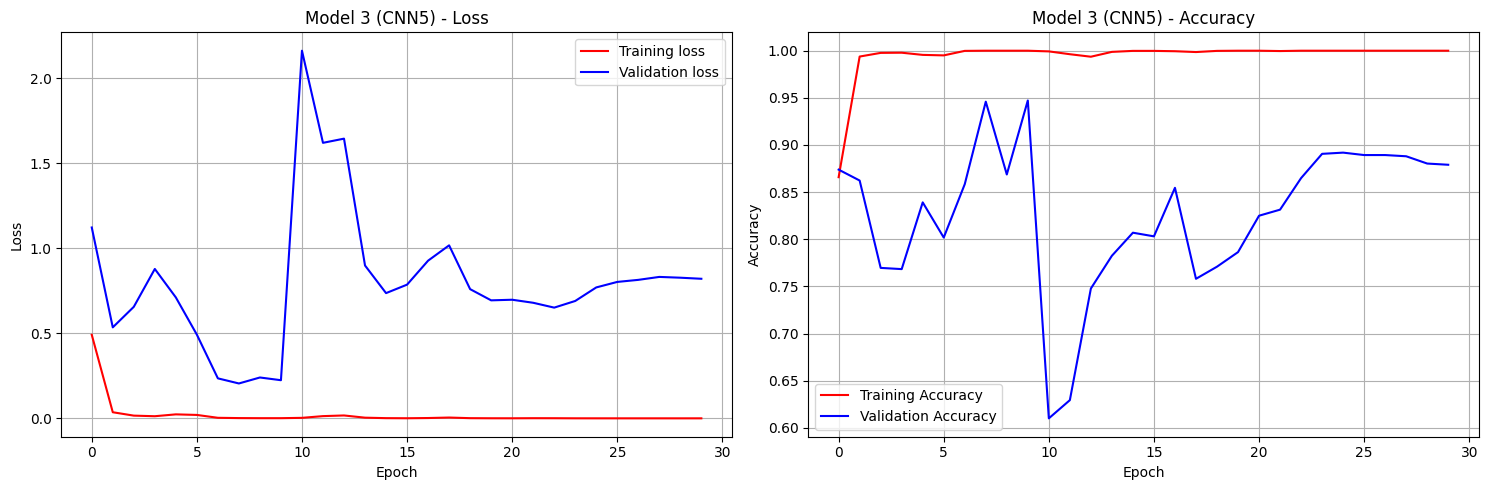

In [102]:
train_loss = history3.history['loss']
train_accuracy = history3.history['sparse_categorical_accuracy']
val_loss = history3.history['val_loss']
val_accuracy = history3.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 3 (CNN5) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 3 (CNN5) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

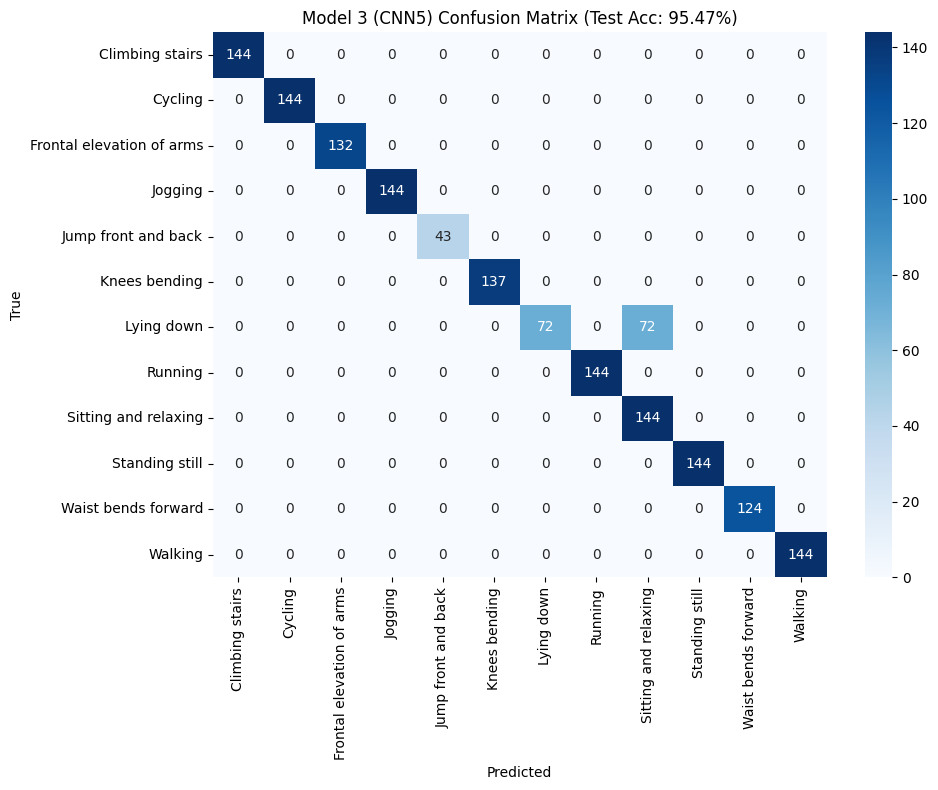

In [103]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 3 (CNN5) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()